# 1. Setup and upload data

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [70]:
path = 'default credit.csv'

df = pd.read_csv(path)
df 

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,BILL_AMT_avg,BILL_AMT_trend,credit utilization ratio
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,689,0,0,0,0,1,1284.000000,3913,0.195650
1,120000,2,2,2,26,-1,2,0,0,0,...,0,1000,1000,1000,0,2000,1,2846.166667,-579,0.022350
2,90000,2,2,2,34,0,0,0,0,0,...,1518,1500,1000,1000,1000,5000,0,16942.166667,13690,0.324878
3,50000,2,2,1,37,0,0,0,0,0,...,2000,2019,1200,1100,1069,1000,0,38555.666667,17443,0.939800
4,50000,1,2,1,57,-1,0,-1,0,0,...,2000,36681,10000,9000,689,679,0,18223.166667,-10514,0.172340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29960,220000,1,3,1,39,0,0,0,0,0,...,8500,20000,5003,3047,5000,1000,0,120891.500000,172968,0.858855
29961,150000,1,3,2,43,-1,-1,-1,-1,0,...,1837,3526,8998,129,0,0,0,3530.333333,1683,0.011220
29962,30000,1,2,2,37,4,3,2,-1,0,...,0,0,22000,4200,2000,3100,1,11749.333333,-15792,0.118833
29963,80000,1,3,1,41,1,-1,0,0,0,...,85900,3409,1178,1926,52964,1804,1,44435.166667,-50589,-0.020563


# 2. Feature Engineering

In [71]:
cat_features = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
con_features = ['AGE', 'LIMIT_BAL', 'BILL_AMT_avg', 'BILL_AMT_trend', 'credit utilization ratio',
                  'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
target = 'default payment next month'

In [72]:
# log transformation for right-skewed data
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

skewed_nonneg = ['AGE', 'LIMIT_BAL'] + [f'PAY_AMT{i}' for i in range(1, 7)]
skewed_signed = ['BILL_AMT_avg', 'BILL_AMT_trend', 'credit utilization ratio']  

for col in skewed_nonneg:
    df[col] = np.log1p(df[col])
for col in skewed_signed:
    df[col] = signed_log1p(df[col])

In [73]:
X = df[cat_features + con_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Training

In [74]:
param_grid = [
    {'penalty': ['l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs']},
    {'penalty': ['l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['liblinear']},
    {'penalty': ['l1'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['liblinear']},
    {'penalty': ['l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['newton-cg']},
    {'penalty': ['l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['newton-cholesky']},
    {'penalty': ['l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['sag']},   
    {'penalty': ['l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['saga']},
    {'penalty': ['l1'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['saga']},
    {'penalty': ['elasticnet'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'l1_ratio': [0.25, 0.5, 0.75], 'solver': ['saga']},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [75]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000),
    param_grid=param_grid,
    scoring='neg_log_loss', # instead of roc_auc
    cv=cv,
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV log loss:', -grid_search.best_score_)

/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_s

Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'newton-cg'}
Best CV log loss: 0.4521186923779328


/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

In [76]:
model = grid_search.best_estimator_

y_pred = model.predict(X_test_scaled)

# Get probability estimates for the test set
probabilities = model.predict_proba(X_test_scaled)

# Display the probability estimates
#for i, prob in enumerate(probabilities):
#    print(f"Sample {i+1}: Class 0 Probability = {prob[0]:.4f}, Class 1 Probability = {prob[1]:.4f}")

# 4. Evaluation

In [77]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.96      0.89      4673
           1       0.66      0.25      0.36      1320

    accuracy                           0.81      5993
   macro avg       0.74      0.60      0.62      5993
weighted avg       0.78      0.81      0.77      5993



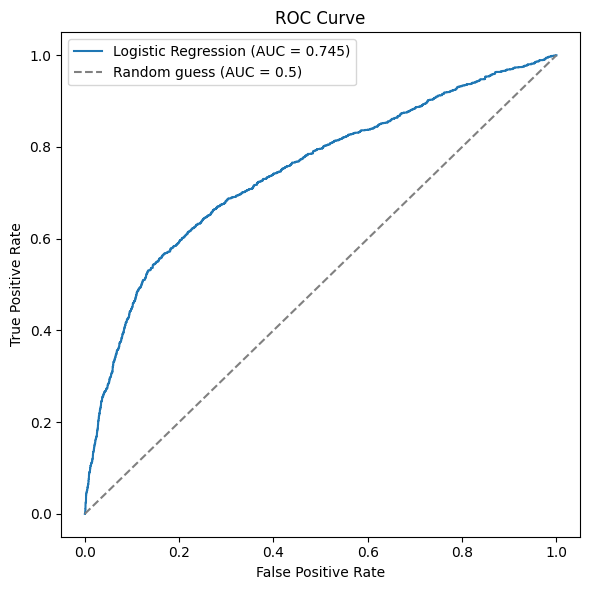

In [78]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()

Text(0.5, 1.0, 'Precision and Recall vs. Threshold')

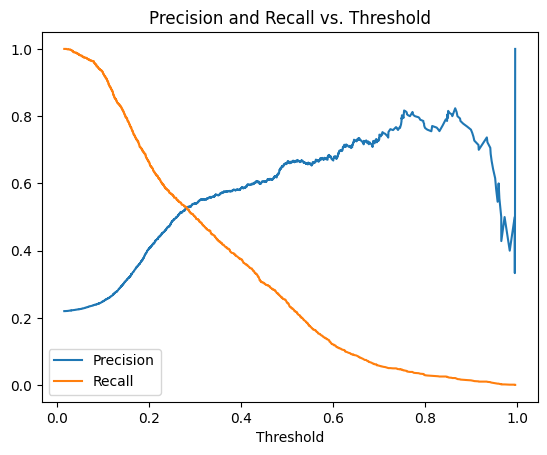

In [79]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision and Recall vs. Threshold')

In [80]:
fn_cost, fp_cost = 4, 1  # illustrative — replace with a defensible ratio
thresholds = np.arange(0.05, 0.95, 0.01)
costs = []
for t in thresholds:
    pred = (y_proba >= t).astype(int)
    fn = ((pred==0) & (y_test==1)).sum()
    fp = ((pred==1) & (y_test==0)).sum()
    costs.append(fn*fn_cost + fp*fp_cost)

best_threshold = thresholds[np.argmin(costs)]
print(f'Best threshold based on cost of FN and FP: {best_threshold}')

Best threshold based on cost of FN and FP: 0.20000000000000004


In [81]:
for label, t in [('Default (0.5)', 0.5), ('Cost-optimal', best_threshold)]:
    pred = (y_proba >= t).astype(int)
    print(f'=== {label} ===')
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, digits=3))

=== Default (0.5) ===
[[4507  166]
 [ 996  324]]
              precision    recall  f1-score   support

           0      0.819     0.964     0.886      4673
           1      0.661     0.245     0.358      1320

    accuracy                          0.806      5993
   macro avg      0.740     0.605     0.622      5993
weighted avg      0.784     0.806     0.770      5993

=== Cost-optimal ===
[[3395 1278]
 [ 445  875]]
              precision    recall  f1-score   support

           0      0.884     0.727     0.798      4673
           1      0.406     0.663     0.504      1320

    accuracy                          0.712      5993
   macro avg      0.645     0.695     0.651      5993
weighted avg      0.779     0.712     0.733      5993



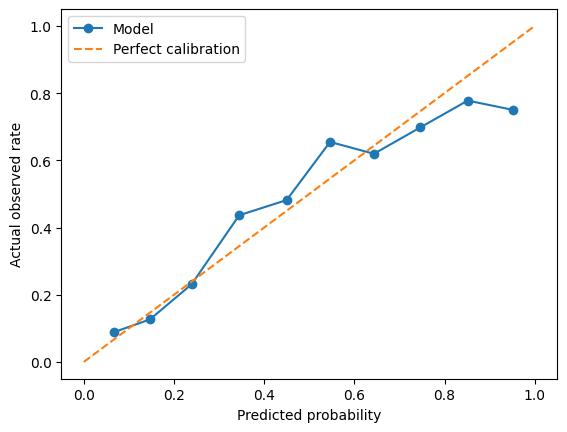

In [82]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel('Predicted probability')
plt.ylabel('Actual observed rate')
plt.legend()